In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)_9절~14절</font>

# 9절. 데이터 그룹화 및 집계

In [5]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [6]:
#  그룹화 방법 2) 그룹핑 할 때 index를 컬럼 데이터로 편입(reset_index()가 필요X)
#    df.groupby(by=[그룹핑할열이름], as_index=False)[함수 적용해서 출력할 열들].기초통계함수()
#    [함수 적용해서 출력할 열들] 생략시 모든 열이 적용됨.
iris.groupby('Species')[ ['Sepal.Length','Sepal.Width'] ].sum()

,Sepal.Length,Sepal.Width
Species,,
setosa,250.3,171.4
versicolor,296.8,138.5
virginica,329.4,148.7


In [7]:
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum   # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [8]:
# setosa, virginica의 집계만
iris_grouped_sum.loc[ ['setosa', 'virginica'] ]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [9]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [10]:
iris_grouped_sum.reset_index(inplace=True) # 인덱스를 컬럼으로 편입시킴

In [11]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [12]:
# setosa, virginica의 집계만
iris_grouped_sum[ (iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica') ]
iris_grouped_sum[iris_grouped_sum.Species.isin( ['setosa', 'virginica'] ) ]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [13]:
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [17]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[ ['Sepal.Length','Sepal.Width'] ]
iris.groupby('Species')[ ['Sepal.Length','Sepal.Width'] ].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [23]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 시리즈로 출력(1차원)
iris.groupby('Species')[ ['Sepal.Length'] ].sum() # 결과가 시리즈로 출력(2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [31]:
# 그룹화 방법 1)
# df.groupby(by=[그룹핑할열이름들], as_index=T or F)[함수 적용해서 출력할 열들].함수명()
# 그룹화 방법 2)
# df.pivot_table( index='그룹핑 할 열들',   values='함수 적용해서 출력할 열들',   aggfunc=함수명(기본값:mean) )
g = iris.pivot_table(index='Species') # values= 안쓰면 모든 열 출력 # aggfunc='mean'

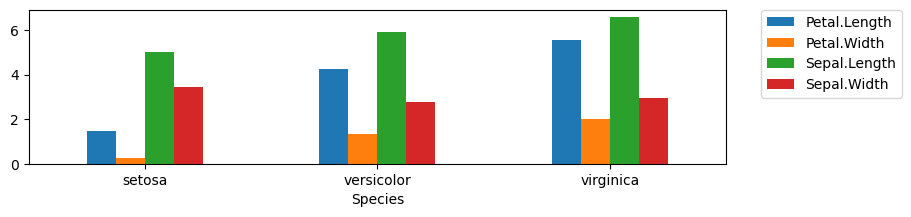

In [42]:
# 범례를 밖으로 : 시각화20page. 판다스60page.
import matplotlib.pyplot as plt
g.plot( kind='bar', figsize=(9,2), rot=0 )
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [52]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')[ ['Sepal.Length'] ].count()
iris['Species'].value_counts() # 정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [70]:
# 임의로 각열마다 결측치를 할당(0번째 열은 결측치1 / 1번째 열은 결측치2 / 2번째 열은 결측치3 / 3번째 열은 결측치 4)
import numpy as np
import random
# random.sample(range(0,150), 3)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan # 1번만 실행

In [73]:
iris.isna().head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,False,False,False,False,False
1,False,False,False,True,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [74]:
# 열별 결측치를 제외한 데이터 개수
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,47,50,49
versicolor,50,49,49,50
virginica,48,50,50,49


### 다중열로 그룹화

In [79]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [90]:
# iris로 다중열 그룹화를 하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species 3그룹, num 6그룹
iris['num'] = np.array( [[i]*25 for i in range(6)] ).flatten() # 25개씩 6개의 그룹
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [109]:
# 종별, num별 합계
r = iris.groupby( ['Species', 'num'] ).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         83.6          35.3          5.7
           1           124.6         84.4          36.6          6.1
versicolor 2           145.3         69.4         107.8         32.3
           3           146.5         69.1         105.2         32.7
virginica  4           164.4         70.4         135.9         51.1
           5           165.0         75.5         131.0         50.2

In [110]:
r.loc[['setosa','virginica']] # setosa와 virginica의 합계만

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         83.6          35.3          5.7
          1           124.6         84.4          36.6          6.1
virginica 4           164.4         70.4         135.9         51.1
          5           165.0         75.5         131.0         50.2

In [111]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,83.6,35.3,5.7
virginica,5,165.0,75.5,131.0,50.2


In [101]:
# 종별, num별 합계
iris.pivot_table(index=['Species', 'num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.470833     0.259091      5.028000     3.483333
           1        1.464000     0.244000      4.984000     3.376000
versicolor 2        4.312000     1.345833      6.054167     2.776000
           3        4.208000     1.308000      5.860000     2.764000
virginica  4        5.662500     2.044000      6.576000     2.933333
           5        5.458333     2.008000      6.600000     3.020000

In [105]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   49.000000  50.000000
             mean    5.006000    5.955102   6.588000
             std     0.352490    0.503348   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   50.000000  49.000000
             mean    3.428571    2.770000   2.977551
             std     0.382971    0.313798   0.324850
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.200000
             max     4.400000    3.400000   3.800000
Petal.Length count  49.000000   50.000000  48.000000
             mean    1.467347    4.260000   5.560417
             std     0.171255    0.469911   0.559536
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  47.000000   49.000000  50.000000
             mean    0.251064    1.326531   2.026000
             std     0.106061    0.199766   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000